In [1]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F
torch.manual_seed(42)

In [3]:
!wget https://raw.githubusercontent.com/AviSoori1x/makeMoE/main/input.txt 

--2026-01-12 08:54:59--  https://raw.githubusercontent.com/AviSoori1x/makeMoE/main/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.006s  

2026-01-12 08:54:59 (166 MB/s) - ‘input.txt’ saved [1115394/1115394]



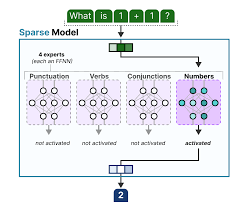

## Mixture of Experts (MoE)
Mixture of Experts (MoE) is a neural network architecture that consists of multiple expert models and a gating mechanism that determines which experts to use for a given input. The main idea behind MoE is to divide the problem space into smaller subspaces, each handled by a specialized expert model. This allows the overall model to be more efficient and effective, as each expert can focus on a specific aspect of the data.

### Key Components of MoE
1. **Experts** : NN which are specialized in different aspects of the input data.
2. **Router/Gating Network** : A NN that takes the input and decides which experts to activate for that input. It outputs a set of weights or probabilities for each expert.
3. **Combiner** : Combines the outputs of the selected experts based on the weights provided by the router.


In [ ]:
## Experts 

class Experts(nn.Module):
    
    """An MLP is used as an expert model."""

    def __init__(self, n_embed, dropout): 
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embed, 4 * n_embed),
            nn.ReLU(),
            nn.Linear(4 * n_embed, n_embed), 
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)
    


In [5]:
## Router - determines which expert network recieves the output for the each token from multi head attention 

num_experts = 4
top_k = 2
n_embed = 32

mh_output = torch.randn(2,4,n_embed)  # (batch size, seq length, n_embed)

topkgate_linear = nn.Linear(n_embed, num_experts) ## Router

logits = topkgate_linear(mh_output)  # (batch size, seq length, num_experts)

print(logits)


tensor([[[ 0.3123,  1.1655, -0.7807, -0.6824],
         [ 0.3673,  0.7938,  0.5621, -0.1175],
         [ 0.0020, -0.2161, -0.2488, -0.5205],
         [-0.8810,  0.0809, -0.1944, -0.4015]],

        [[-0.1735, -0.0627, -1.7612,  0.8458],
         [-0.1540, -0.5238,  0.6834, -0.9940],
         [ 0.3456, -0.0338, -0.8101,  0.0095],
         [-1.1411,  0.6816, -1.0162,  0.8528]]], grad_fn=<ViewBackward0>)


In [6]:
## selecting top k experts for each token

topk_logits, topk_indices  = logits.topk(top_k, dim=-1)  # Get the top k logits and their indices

topk_logits, topk_indices

(tensor([[[ 1.1655,  0.3123],
          [ 0.7938,  0.5621],
          [ 0.0020, -0.2161],
          [ 0.0809, -0.1944]],
 
         [[ 0.8458, -0.0627],
          [ 0.6834, -0.1540],
          [ 0.3456,  0.0095],
          [ 0.8528,  0.6816]]], grad_fn=<TopkBackward0>),
 tensor([[[1, 0],
          [1, 2],
          [0, 1],
          [1, 2]],
 
         [[3, 1],
          [2, 0],
          [0, 3],
          [3, 1]]]))

In [8]:
## use -inf and 0 to create a mask for the experts not selected and apply softmax to get the probabilities for the selected experts

zeros = torch.full_like(logits, float('-inf'))  # Create a tensor filled with -inf
masked_logits = zeros.scatter(-1, topk_indices, topk_logits)  # Scatter the top k logits into the -inf tensor
masked_logits

tensor([[[ 0.3123,  1.1655,    -inf,    -inf],
         [   -inf,  0.7938,  0.5621,    -inf],
         [ 0.0020, -0.2161,    -inf,    -inf],
         [   -inf,  0.0809, -0.1944,    -inf]],

        [[   -inf, -0.0627,    -inf,  0.8458],
         [-0.1540,    -inf,  0.6834,    -inf],
         [ 0.3456,    -inf,    -inf,  0.0095],
         [   -inf,  0.6816,    -inf,  0.8528]]], grad_fn=<ScatterBackward0>)

In [9]:
probs = F.softmax(masked_logits, dim=-1)  # Apply softmax to get probabilities
probs

tensor([[[0.2988, 0.7012, 0.0000, 0.0000],
         [0.0000, 0.5577, 0.4423, 0.0000],
         [0.5543, 0.4457, 0.0000, 0.0000],
         [0.0000, 0.5684, 0.4316, 0.0000]],

        [[0.0000, 0.2873, 0.0000, 0.7127],
         [0.3021, 0.0000, 0.6979, 0.0000],
         [0.5832, 0.0000, 0.0000, 0.4168],
         [0.0000, 0.4573, 0.0000, 0.5427]]], grad_fn=<SoftmaxBackward0>)

In [ ]:
## Creating topkrouter class 

class TopKRouter(nn.Module):
    def __init__(self, n_embed, num_experts, top_k):
        super(TopKRouter, self).__init__()
        self.top_k = top_k 
        self.linear = nn.Linear(n_embed, num_experts)

    def forward(self, mh_output):
        logits = self.linear(mh_output)
        top_k_logits, indices = logits.topk(self.top_k, dim = -1)
        zeroes = torch.full_like(logits, float('-inf'))
        sparse_logits = zeros.scatter(-1, indices, top_k_logits)
        router_output = F.softmax(sparse_logits, dim = -1)
        return router_output, indices

    
        